# Redes Neuronales

In [7]:
import numpy as np

from sklearn import neural_network
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from mlutils import load_dataset
import matplotlib.pyplot as plt

%matplotlib inline

In [6]:
!pip install matplotlib pandas 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 16.2 MB/s eta 0:00:00m eta 0:00:01:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 13.1 MB/s eta 0:00:000:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 10.4 MB/s eta 0:00:0031m10.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 11.5 MB/s eta 0:00:00m eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib] 7/8 [matplotlib]


## Repaso de algunas funciones de activación

### ReLU

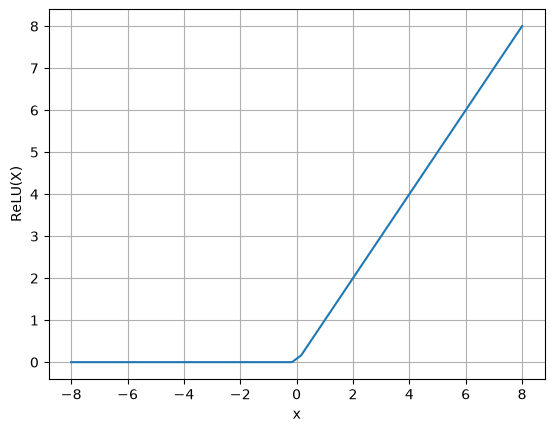

In [8]:
eje_x = np.linspace(-8,8)

def ReLU(x):
    return np.array([xi if xi >= 0 else 0 for xi in x])

plt.plot(eje_x, ReLU(eje_x))
plt.grid()
plt.xlabel('x')
plt.ylabel('ReLU(X)')
plt.show()

### Sigmoide

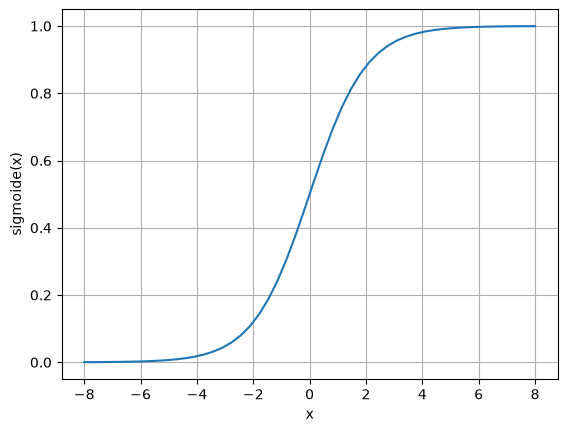

In [9]:
def sigmoide(x):
    return 1.0 / (1 + np.exp(-x))

plt.plot(eje_x, sigmoide(eje_x))
plt.grid()
plt.xlabel('x')
plt.ylabel('sigmoide(x)')
plt.show()

### Tangente hiperbólica

Text(0, 0.5, 'tanh(x)')

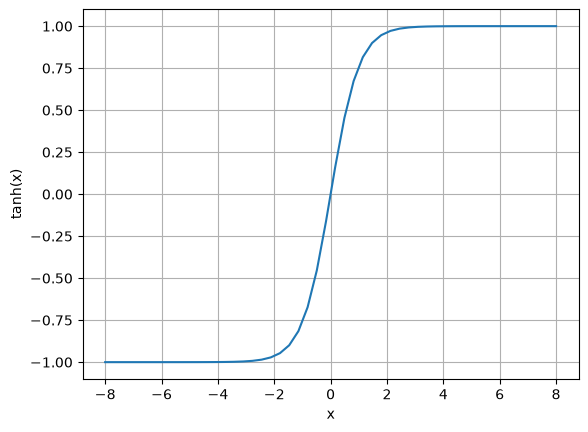

In [10]:
plt.plot(eje_x, np.tanh(eje_x))
plt.grid()
plt.xlabel('x')
plt.ylabel('tanh(x)')

## El problema: Determinar si una imagen tiene o no tiene un gato, dado un conjunto de datos con etiquetas.

<table>
  <tr>
    <th>Cat</th>
    <td> <img src="images/cat1.jpg" width="150"></td>
    <td> <img src="images/cat2.png" width="150"></td>
   </tr> 
   <tr>
      <th>Non Cat</th>
      <td> <img src="images/no_cat1.jpeg" width="150"></td>
      <td> <img src="images/no_cat2.jpg" width="150"></td>
  </tr>
</table>


In [11]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

## Normalización

útil para que no haya valores muy grandes de gradiente

In [12]:
X_train = X_train_orig.reshape(X_train_orig.shape[0], -1)
X_test = X_test_orig.reshape(X_test_orig.shape[0], -1)
X_train = X_train/255.
X_test = X_test/255.

Y_train = Y_train_orig.T
Y_test = Y_test_orig.T

Observams algún caso

y = [1], it's a 'cat' picture.


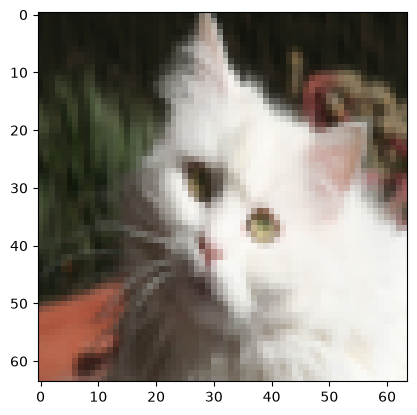

In [13]:
index = 102
# print (X_train[index].reshape(()))
plt.imshow(X_train_orig[index])
print ("y = " + str(Y_train[index]) + ", it's a '" + classes[np.squeeze(Y_train[index])].decode("utf-8") +  "' picture.")

## Implementación en Sklearn

[Documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier.predict_proba)

In [14]:
clf = neural_network.MLPClassifier(
    solver='sgd',
    alpha=1e-4, 
    hidden_layer_sizes=(5),
    learning_rate='constant',
    learning_rate_init=0.001,
    batch_size=20,
    random_state=1,
    max_iter=1000,
    verbose=True)

In [15]:
clf.fit(X_train, Y_train.ravel())

Iteration 1, loss = 0.73637257
Iteration 2, loss = 0.72814070
Iteration 3, loss = 0.72206618
Iteration 4, loss = 0.71784621
Iteration 5, loss = 0.71409639
Iteration 6, loss = 0.70989772
Iteration 7, loss = 0.70659742
Iteration 8, loss = 0.70302878
Iteration 9, loss = 0.69942054
Iteration 10, loss = 0.69628679
Iteration 11, loss = 0.69333155
Iteration 12, loss = 0.69071555
Iteration 13, loss = 0.68790359
Iteration 14, loss = 0.68550357
Iteration 15, loss = 0.68305682
Iteration 16, loss = 0.68085484
Iteration 17, loss = 0.67877683
Iteration 18, loss = 0.67667372
Iteration 19, loss = 0.67460631
Iteration 20, loss = 0.67271247
Iteration 21, loss = 0.67108388
Iteration 22, loss = 0.66907659
Iteration 23, loss = 0.66728475
Iteration 24, loss = 0.66605890
Iteration 25, loss = 0.66441623
Iteration 26, loss = 0.66304044
Iteration 27, loss = 0.66154193
Iteration 28, loss = 0.66013801
Iteration 29, loss = 0.65879022
Iteration 30, loss = 0.65764886
Iteration 31, loss = 0.65623976
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.",5
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",20
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",1
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5


In [16]:
neural_network.MLPClassifier?

Init signature:
neural_network.MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    *,
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=None,
    tol=0.0001,
    verbose=False,
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True,
    early_stopping=False,
    validation_fraction=0.1,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    n_iter_no_change=10,
    max_fun=15000,
)
Docstring:     
Multi-layer Perceptron classifier.

This model optimizes the log-loss function using LBFGS or stochastic
gradient descent.

.. versionadded:: 0.18

Parameters
----------
hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
    The ith element represents the number of neurons in the ith
    hidden layer.

activation : {'identity', 'logistic', 'tanh', 'relu'}, default='relu'
    Activation function for 

Calculemos cuántos parámetros tiene el modelo:

In [17]:
total_params = 0
for case, name in zip(clf.coefs_, ('wi','bias')):
    print(name, '=', np.size(case))
    total_params += np.size(case)

for case, name in zip(clf.intercepts_, ('wi','bias')):
    print(name, '=', np.size(case))
    total_params += np.size(case)

print('total params = ', total_params)

wi = 61440
bias = 5
wi = 5
bias = 1
total params =  61451


Veamos algunas predicciones de probabilidad:

In [18]:
np.round(np.exp(clf.predict_log_proba(X_train)),1)

array([[0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0. , 1. ],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9, 0.1],
       [0. , 1. ],
       [0.9, 0.1],
       [0.9,

Podemos calcular la Accuracy del modelo en el conjunto de datos de entrenamiento:

In [19]:
predictions = clf.predict(X_train)
print (f'Accuracy: {accuracy_score(Y_train, predictions)*100:.2f}')

Accuracy: 94.74


Y ver cuánto da en el conjunto de datos de prueba

In [20]:
predictions = clf.predict(X_test)
print(f'Accuracy: {accuracy_score(Y_test, predictions)*100:.2f}')

print('i, match, case (1=cat, 0=nocat)')
for i, match in enumerate(predictions == Y_test.ravel()):
    if i<15:
        print(i,match, Y_test[i])


Accuracy: 68.00
i, match, case (1=cat, 0=nocat)
0 True [1]
1 True [1]
2 True [1]
3 True [1]
4 True [1]
5 False [0]
6 True [1]
7 True [1]
8 True [1]
9 True [1]
10 False [1]
11 True [1]
12 True [1]
13 False [0]
14 True [0]


Veamos algunas predicciones:

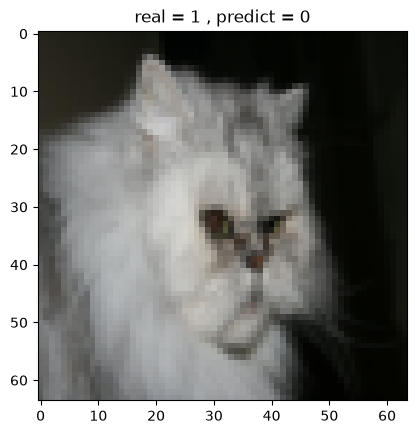

In [21]:
idx = 10
num_px = X_train_orig.shape[1]
plt.imshow(X_test[idx].reshape((num_px, num_px, 3)))
plt.title('real = '+str(Y_test[idx].item())+f' , predict = {predictions[idx]}')
plt.show()


Podemos ver cuál es la función de activación de salida

In [22]:
clf.out_activation_

'logistic'

# Keras

[Documentación](https://keras.io/api/models/model_training_apis/)

Implementemos el mismo clasificador pero construyendo el perceptrón múltiple con Keras

In [4]:
!pip install tensorflow scikit-learn

  Using cached tensorflow-2.21.0-cp313-cp313-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.2.2-cp313-cp313-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (7.4 kB)
  Using cached grpcio-1.81.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.7 kB)
  Using cached h5py-3.14.0-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (

In [23]:
#import theano
#theano.config.optimizer = 'None'
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.regularizers import L2
from keras.utils import set_random_seed

set_random_seed(2)

I0000 00:00:1782254661.846680  450832 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782254661.855628  450832 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782254662.661429  450832 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782254664.763154  450832 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

[Dense layer](https://keras.io/api/layers/core_layers/dense/):

$y = activation(kernel \cdot X+bias)$


Definimos el modelo

In [24]:
model = Sequential([
    Dense(5, input_shape=(X_train.shape[1],), activation="relu", kernel_regularizer=L2(1e-4)),
    Dense(1, activation="sigmoid", kernel_regularizer=L2(1e-4))
])

/home/diego/Nobu/Trabajos/DiploDatos/diplodatos_venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1782254676.148715  450832 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Definimos qué optimizador vamos a utilizar, qué función de costo vamos a optimizar y qué métricas almacenar:

In [25]:
opt = SGD(learning_rate=0.001)
model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=["acc"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │        61,445 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,451 (240.04 KB)

 Trainable params: 61,451 (240.04 KB)

 Non-trainable params: 0 (0.00 B)

Ajustamos el modelo:

In [26]:
model.fit(X_train, Y_train.ravel(), batch_size=20, epochs=500, validation_data=(X_test, Y_test))#, workers=2)

Epoch 1/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.6172 - loss: 0.6770 - val_acc: 0.3400 - val_loss: 1.1373
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6603 - loss: 0.6509 - val_acc: 0.3400 - val_loss: 1.1245
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.6603 - loss: 0.6396 - val_acc: 0.3400 - val_loss: 1.1124
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6651 - loss: 0.6296 - val_acc: 0.3400 - val_loss: 1.1009
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.6651 - loss: 0.6210 - val_acc: 0.3400 - val_loss: 1.0864
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6746 - loss: 0.6134 - val_acc: 0.3400 - val_loss: 1.1358
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6794 - loss: 0.6066 - val_acc: 0.3400 - val_loss: 1.1436
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6842 - loss: 0.5991 - val_acc: 0.3400 - val_loss: 1.1147
Epoch 9/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.698

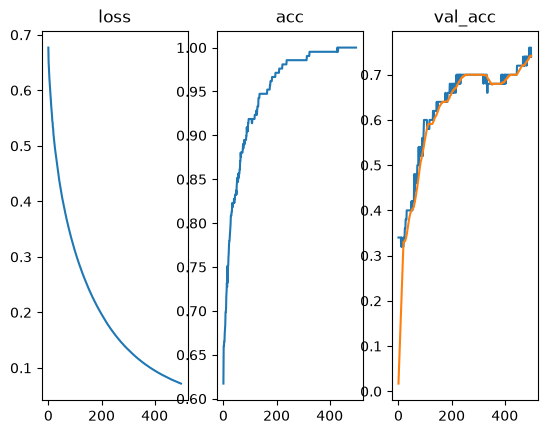

In [27]:
plt.subplot(1,3,1)
plt.plot(model.history.history['loss'])
plt.title('loss')
plt.subplot(1,3,2)
plt.plot(model.history.history['acc'])
plt.title('acc')
plt.subplot(1,3,3)
def moving_average(a, n=3) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret/n
plt.plot(model.history.history['val_acc'])
plt.plot(moving_average(model.history.history['val_acc'],n=20))
plt.title('val_acc')
plt.show()

Podemos acceder a los pesos y almacenarlos si es que nos interesa guardar el modelo:

In [28]:
wnew = model.weights
wnew

[<Variable path=sequential/dense/kernel, shape=(12288, 5), dtype=float32, value=[[ 1.45653440e-02 -2.69143656e-02  1.35297258e-03  1.44921038e-02
    1.54732019e-02]
  [ 1.09893503e-02  2.89133210e-02 -2.51727551e-02 -1.64606459e-02
   -6.06026547e-03]
  [ 5.80722583e-04 -1.67319458e-02  1.53695457e-02  1.43629557e-03
   -2.15487201e-02]
  ...
  [-1.14117879e-02  1.59715861e-02 -2.83553861e-02 -2.06497367e-02
    4.76302486e-03]
  [ 2.12243609e-02  1.06083406e-02 -3.15194130e-02 -1.97842009e-02
   -4.10104636e-03]
  [ 1.14921145e-02  2.26032571e-03 -6.57292621e-05  2.12310385e-02
   -1.84650067e-02]]>,
 <Variable path=sequential/dense/bias, shape=(5,), dtype=float32, value=[ 0.00347993  0.02122581 -0.01306361 -0.01308409 -0.00028944]>,
 <Variable path=sequential/dense_1/kernel, shape=(5, 1), dtype=float32, value=[[ 0.94525343]
  [-1.3442897 ]
  [ 0.8908624 ]
  [ 0.78952223]
  [ 0.10329972]]>,
 <Variable path=sequential/dense_1/bias, shape=(1,), dtype=float32, value=[-0.02037383]>]

Existe el método evaluate para evaluar el modelo en el conjunto de datos de prueba:

In [29]:
model.evaluate(x=X_test, y=Y_test, batch_size=100,)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.7400 - loss: 0.7662


[0.7662141919136047, 0.7400000095367432]

El método predict permite predecir utilizando el modelo entrenado

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
y = 0, you predicted that it is a "non-cat" picture.


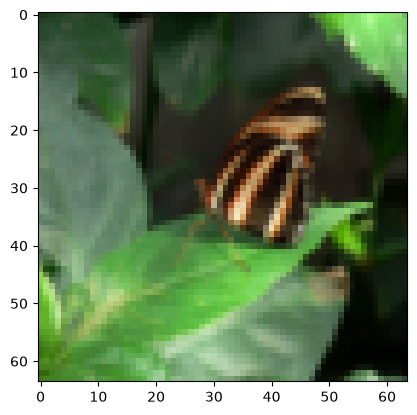

In [30]:
prediction = model.predict(x=X_test)
prediction[prediction>0.5] = 1
prediction[prediction<=0.5] = 0
prediction = prediction.squeeze()

index = 5
num_px = X_train_orig[index].shape[0]

plt.imshow(X_test[index,:].reshape((num_px, num_px, 3)))
print ("y = " + str(Y_test[index,0]) + ", you predicted that it is a \"" + classes[int(prediction[index])].decode("utf-8") +  "\" picture.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
y = 1, you predicted that it is a "cat" picture.


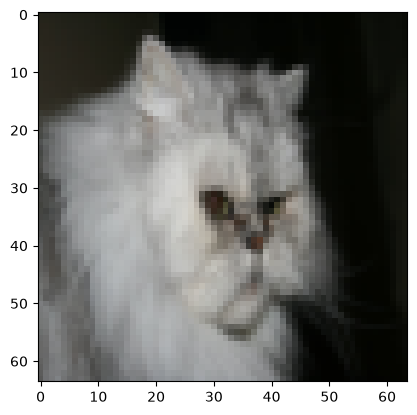

In [31]:
prediction = model.predict(x=X_test)
prediction[prediction>0.5] = 1
prediction[prediction<=0.5] = 0
prediction = prediction.squeeze()

index = 10
num_px = X_train_orig[index].shape[0]

plt.imshow(X_test[index,:].reshape((num_px, num_px, 3)))
print ("y = " + str(Y_test[index,0]) + ", you predicted that it is a \"" + classes[int(prediction[index])].decode("utf-8") +  "\" picture.")

Veamos algunas métricas de bondad de modelo:

              precision    recall  f1-score   support

           0       0.60      0.71      0.65        17
           1       0.83      0.76      0.79        33

    accuracy                           0.74        50
   macro avg       0.72      0.73      0.72        50
weighted avg       0.75      0.74      0.74        50



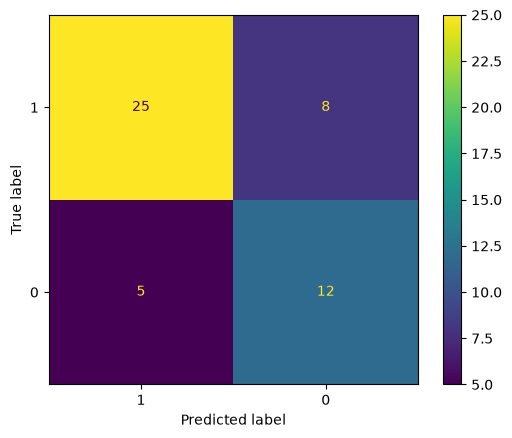

In [32]:
print(classification_report(Y_test, prediction))
ConfusionMatrixDisplay.from_predictions(Y_test, prediction,labels=(1,0))

# Representación gráfica de la red

In [39]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [visualkeras]


In [40]:
import visualkeras #hay que instalarlo
visualkeras.layered_view(model).show()#, legend=True)

/home/diego/Nobu/Trabajos/DiploDatos/diplodatos_venv/lib/python3.13/site-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


AttributeError: 'Dense' object has no attribute 'output_shape'

In [43]:
from keras_visualizer import visualizer #hay que instalarlo
visualizer(model, file_name='images/keras_visualizer', file_format='png', view=False)
#visualizer(model, file_name='graph', file_format=None, view=True, settings=None)
plt.imshow(plt.imread('images/keras_visualizer.png'), aspect=1.5)

lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines, Pshortestpath failed
lib/pathplan/shortest.c:95: cannot realloc pnls
Error: in routesplines

ValueError: [Keras Visualizer] Error while visualizing: <class 'Exception'>

In [37]:
#!pip install pydot
from keras.utils import plot_model

plot_model(model, 
to_file='images/model.png',
show_shapes=True,
show_layer_names=False,
show_layer_activations=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


# Ejemplo de uso más interesante

Ahora vamos a centrarnos en entrenar un perceptrón multicapa en un conjunto de datos más grande, como lo es el conjunto mnist de dígitos escritos a mano

In [ ]:
from keras.models import Sequential
from keras.layers import Dense , Activation, Dropout
from keras.optimizers import Adam
from keras.datasets import mnist

In [ ]:
# cargamos el conjunto de datos
(x_train, y_train),(x_test, y_test) = mnist.load_data()
unique, counts = np.unique(y_train, return_counts=True)
print("Etiquetas de entrenamiento: ", dict(zip(unique, counts)))
unique, counts = np.unique(y_test, return_counts=True)
print("Etiquetas de prueba: ", dict(zip(unique, counts)))


Muestreamos algunos dígitos:

In [ ]:
cantidad = 25
indexes = np.random.randint(0, x_train.shape[0], size=cantidad)
images = x_train[indexes]
labels = y_train[indexes]

plt.figure(figsize=(5,5))
for i in range(len(indexes)):
    plt.subplot(5, 5, i + 1)
    image = images[i]
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    
plt.show()

### One-Hot-Encoding

Primero transformamos las etiquetas (números del 0 al 9) a vectores de dimensión 10 en los cuáles sólo será no nulo el elemento cuyo índice de órden sea igual a la etiqueta. Esto es:

$0 = (1,0,0,0,0,0,0,0,0,0)$

$1 = (0,1,0,0,0,0,0,0,0,0)$

$2 = (0,0,1,0,0,0,0,0,0,0)$

$3 = (0,0,0,1,0,0,0,0,0,0)$

$4 = (0,0,0,0,1,0,0,0,0,0)$

$5 = (0,0,0,0,0,1,0,0,0,0)$

$6 = (0,0,0,0,0,0,1,0,0,0)$

$7 = (0,0,0,0,0,0,0,1,0,0)$

$8 = (0,0,0,0,0,0,0,0,1,0)$

$9 = (0,0,0,0,0,0,0,0,0,1)$


In [ ]:
from keras.utils import to_categorical, plot_model

In [ ]:
num_labels = len(np.unique(y_train))
print(num_labels)

In [ ]:
y_train

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
y_train

### Preprocesamiento de los datos

- Suele ser conveniente normalizar los datos para evitar valores muy grandes de gradiente que puedan dificultar el proceso de aprendizaje. Los valores de los pixeles están en escala de grises de 0 a 255.

- El perceptrón múltiple debe aceptar un tensor 1-dimensional, así que hay que transformar los datos de entrada.

In [ ]:
# Tamaño de la imagen, que se asume cuadrada
image_size = x_train.shape[1]
input_size = image_size * image_size
input_size

In [ ]:
# transformación y normalización
x_train = np.reshape(x_train, [-1, input_size])
x_train = x_train.astype('float32') / 255
x_test = np.reshape(x_test, [-1, input_size])
x_test = x_test.astype('float32') / 255

In [ ]:
x_train.shape

### Parámetros de la red

In [ ]:
# network parameters
batch_size = 128
hidden_units = 256
dropout = 0.45

### Diseño de la arquitectura de la red

- Proponemos un diseño con 3 capas ocultas. 

- Las primeras dos capas serán idénticas y completamente conectadas. Tendrán funciones de activación ReLU y implementaremos Dropout.

- Se eligirán 256 neuronas por capa oculta. Este número podría testearse a prueba y error. Se suelen usar múltiplos de 2 como 128, 512, 1024. En un análisis previo se vio que 256 funciona mejor.

In [ ]:
modelo_mnist = Sequential()
modelo_mnist.add(Dense(hidden_units, input_dim=input_size, kernel_regularizer=L2(0.001)))
modelo_mnist.add(Activation('relu'))
modelo_mnist.add(Dropout(dropout))
modelo_mnist.add(Dense(hidden_units, kernel_regularizer=L2(0.001)))
modelo_mnist.add(Activation('relu'))
modelo_mnist.add(Dropout(dropout))
modelo_mnist.add(Dense(num_labels))
modelo_mnist.add(Activation('softmax'))
modelo_mnist.summary()

Esto sale de:

- Entrada a primera capa: $784 \times 256 + 256 = 200960$
- primera a Segunda capa: $256 \times 256 + 256 = 65792$
- segunda capa a salida: $10 \times 256 + 10 = 2570$
- Total : $200960 + 65972 + 2570 = 269322$

In [ ]:
plot_model(modelo_mnist, 
to_file='images/modelo_mnist.png',
show_shapes=True,
show_layer_names=False,
show_layer_activations=True)

In [ ]:
opt = Adam(learning_rate=0.001)
modelo_mnist.compile(loss='categorical_crossentropy', 
              optimizer=opt,
              metrics=["acc"])

In [ ]:
modelo_mnist.fit(x_train, y_train, epochs=10,
 batch_size=batch_size,validation_data=(x_test, y_test))#, workers=1)

In [ ]:
plt.subplot(1,2,1)
plt.plot(modelo_mnist.history.history['loss'], label='train')
plt.plot(modelo_mnist.history.history['val_loss'],label='test')
plt.legend()
plt.title('loss')
plt.subplot(1,2,2)
plt.plot(modelo_mnist.history.history['acc'],label='train')
plt.plot(modelo_mnist.history.history['val_acc'],label='test')
plt.ylim(0.5,1)
plt.title('acc')
plt.legend()
plt.show()

https://keras.io/getting_started/faq/#why-is-the-training-loss-much-higher-than-the-testing-loss

### Sanity check
Overfit a tiny subset of data. Before training on the full dataset try to train on a tiny portion (e.g. 20 examples) of your data and make sure you can achieve zero cost. For this experiment it’s also best to set regularization to zero, otherwise this can prevent you from getting zero cost. Unless you pass this sanity check with a small dataset it is not worth proceeding to the full dataset. Note that it may happen that you can overfit very small dataset but still have an incorrect implementation. For instance, if your datapoints’ features are random due to some bug, then it will be possible to overfit your small training set but you will never notice any generalization when you fold it your full dataset.

[referencia](https://cs231n.github.io/neural-networks-3/#sanitycheck)

Observamos que cada predicción es un array con 10 números, cuyo máximo valor corresponde a la clase predicha.

In [ ]:
prediction = modelo_mnist.predict(x=x_test)
prediction

Podemos obtener la etiqueta predicha utilizando la función np.argmax

In [ ]:
def get_label(x):
    return np.argmax(x)

get_label(prediction[0])

Acá tienen unas funciones que pueden servir para observar los resultados predichos:

In [ ]:
def plot_image(i, predictions_array, true_label, img, num_px):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i].reshape((num_px, num_px, 1))
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)
  
  predicted_label = np.argmax(predictions_array)
  true_label = np.argmax(true_label)
  plt.title(f'True: {true_label}, Predicted: {predicted_label}')
  

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks(np.linspace(0,1,11).round(2))
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)
  true_label = np.argmax(true_label)
  
  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

In [ ]:
i = 18
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
num_px = 28
plot_image(i, prediction[i], y_test, x_test, num_px)
plt.subplot(1,2,2)
plot_value_array(i, prediction[i],  y_test)
plt.title('Probabilidad de cada clase')
plt.show()

## Ejemplos extras

- El ejemplo de esta notebook fue basado en este [enlace](https://www.kaggle.com/code/prashant111/mnist-deep-neural-network-with-keras/notebook).

- Va otro [ejemplo](https://www.tensorflow.org/tutorials/keras/classification?hl=es-419) de clasificación de imágenes de ropa. 

- Dejo un [ejemplo](https://www.tensorflow.org/tutorials/keras/regression?hl=es-419) de regresión con un perceptrón múltiple en keras para que no crean que es todo sobre imágenes.
